# RAGWire Setup and First Retrieval

**Stack:** Ollama · Qdrant (local)

Progressive journey:
- Ingest a single document and retrieve chunks
- Scale to multiple companies
- Explore metadata and add filters
- Build an agent — simple first, then filter-aware

## 1. Setup

In [ ]:
from dotenv import load_dotenv
load_dotenv()

from ragwire import RAGWire, setup_logging
import ragwire

print(ragwire.__version__)


c:\Users\aijul\Desktop\RAGWire-Prod-RAG-main\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


1.2.8


: 

In [2]:
logger = setup_logging(log_level="INFO")

## 2. Ingest a Single Document and Retrieve

**Model:** `qwen3.5:9b` · **Embedding:** `qwen3-embedding:0.6b` · **Vector Store:** Qdrant (local)

In [64]:
rag = RAGWire('config.yaml')

2026-04-10 18:37:46,203 - ragwire.core.pipeline - INFO - Loading configuration from config.yaml
2026-04-10 18:37:46,233 - ragwire.core.pipeline - INFO - Document loader initialized
2026-04-10 18:37:46,234 - ragwire.core.pipeline - INFO - Text splitter initialized (strategy=markdown, chunk_size=10000)
2026-04-10 18:37:46,244 - ragwire.core.pipeline - INFO - Embedding model initialized (provider=ollama)
2026-04-10 18:37:46,258 - ragwire.core.pipeline - INFO - Metadata extractor loaded from: finance_metadata.yaml
2026-04-10 18:37:46,258 - ragwire.core.pipeline - INFO - LLM initialized for metadata extraction (provider=ollama, model=qwen3.5:9b)
2026-04-10 18:37:46,271 - ragwire.vectorstores.qdrant_store - INFO - Connected to Qdrant at http://localhost:6333
2026-04-10 18:37:46,291 - ragwire.core.pipeline - INFO - Using existing collection: finance-rag-ollama
2026-04-10 18:37:49,564 - ragwire.core.pipeline - INFO - Vector store initialized
2026-04-10 18:37:49,565 - ragwire.core.pipeline - IN

In [21]:
stats = rag.ingest_documents(["../data/finance_data/Apple_10k_2025.pdf"])

2026-04-10 14:38:24,643 - ragwire.core.pipeline - INFO - Starting ingestion of 1 documents


Ingesting:   0%|          | 0/1 [00:00<?, ?file/s]

2026-04-10 14:38:24,654 - ragwire.core.pipeline - INFO - Skipping (already ingested): ../data/finance_data/Apple_10k_2025.pdf


Ingesting: 100%|██████████| 1/1 [00:00<00:00, 102.00file/s]

2026-04-10 14:38:24,826 - ragwire.core.pipeline - INFO - Ingestion complete: 0/1 documents


In [22]:
stats = rag.ingest_documents(["../data/finance_data/Apple_10k_2025.pdf"])

2026-04-10 14:38:25,564 - ragwire.core.pipeline - INFO - Starting ingestion of 1 documents


Ingesting:   0%|          | 0/1 [00:00<?, ?file/s]

2026-04-10 14:38:25,598 - ragwire.core.pipeline - INFO - Skipping (already ingested): ../data/finance_data/Apple_10k_2025.pdf


Ingesting: 100%|██████████| 1/1 [00:00<00:00, 30.47file/s]

2026-04-10 14:38:25,751 - ragwire.core.pipeline - INFO - Ingestion complete: 0/1 documents


In [23]:
results = rag.retrieve("What is the apple's revenue?")

2026-04-10 14:38:26,212 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: What is the apple's revenue?...


In [24]:
results

[Document(metadata={'source': '../data/finance_data/Apple_10k_2025.pdf', 'file_name': 'Apple_10k_2025.pdf', 'file_type': 'pdf', 'file_hash': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab', 'chunk_id': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab_16', 'chunk_hash': '60b8d552baec48866282206f62d1d54dad52bc158891d1dcf5f9849c24cf4082', 'chunk_index': 16, 'total_chunks': 35, 'created_at': '2026-04-10T09:05:19.756089+00:00', 'company_name': 'apple inc.', 'doc_type': '10-k', 'fiscal_year': 2025, 'fiscal_quarter': 'null', '_id': '9024d4a6-a94d-4bf4-a486-ab6667844564', '_collection_name': 'finance-rag-ollama'}, page_content='Earnings per share:\n\nBasic\nDiluted\n\nShares used in computing earnings per share:\n\nBasic\n\nDiluted\n\nSeptember 27,\n2025\n\nYears ended\n\nSeptember 28,\n2024\n\nSeptember 30,\n2023\n\n$\n\n$\n\n$\n$\n\n307,003  $\n109,158\n\n416,161\n\n294,866  $\n96,169\n\n391,035\n\n194,116\n26,844\n\n220,960\n\n195,201\n\n34,550\n27,601\n6

# RAGWire and Agentic RAG
- Upload set of documents
- Retrieval 
- Agentic RAG

## 3. Scale to Multiple Companies

Ingest all three 10-K filings at once. RAGWire deduplicates — re-running skips already-ingested files.

In [36]:
rag.ingest_directory('../data/finance_data')

2026-04-10 17:21:44,545 - ragwire.core.pipeline - INFO - Found 6 file(s) in ../data/finance_data
2026-04-10 17:21:44,546 - ragwire.core.pipeline - INFO - Starting ingestion of 6 documents


Ingesting:   0%|          | 0/6 [00:00<?, ?file/s]

2026-04-10 17:23:01,052 - ragwire.core.pipeline - INFO - Processed ..\data\finance_data\amazon 10-k 2024.pdf: 39 chunks


Ingesting:  17%|█▋        | 1/6 [01:16<06:22, 76.51s/file]

2026-04-10 17:23:01,078 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\amazon 10k 2025.pdf
2026-04-10 17:24:05,886 - ragwire.core.pipeline - INFO - Processed ..\data\finance_data\apple 10-k 2024.pdf: 53 chunks


Ingesting:  50%|█████     | 3/6 [02:21<02:11, 43.85s/file]

2026-04-10 17:24:05,895 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\Apple_10k_2025.pdf
2026-04-10 17:24:05,904 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\finance_data\GOOG-10-K-2025.pdf
2026-04-10 17:25:34,878 - ragwire.core.pipeline - INFO - Processed ..\data\finance_data\google 10-k 2024.pdf: 49 chunks


Ingesting: 100%|██████████| 6/6 [03:50<00:00, 38.39s/file]

2026-04-10 17:25:35,024 - ragwire.core.pipeline - INFO - Ingestion complete: 3/6 documents


{'total': 6,
 'processed': 3,
 'skipped': 3,
 'failed': 0,
 'chunks_created': 141,
 'errors': []}

## 4. Explore Metadata

RAGWire extracts company name, doc type, and fiscal year during ingestion. Let's inspect what's stored.

In [26]:
rag.discover_metadata_fields()

['source',
 'file_name',
 'file_type',
 'file_hash',
 'chunk_id',
 'chunk_hash',
 'chunk_index',
 'total_chunks',
 'created_at',
 'company_name',
 'doc_type',
 'fiscal_year',
 'fiscal_quarter']

In [28]:
rag.filter_fields

['company_name', 'doc_type', 'fiscal_year', 'fiscal_quarter']

## 5. Manual Metadata Filters

The simple agent above can mix up companies when all three are in the same collection.
Filters let us pin retrieval to a specific company, year, or doc type.

In [29]:
query = "what is apple's revenue in 2025?"
results = rag.retrieve(query=query)

2026-04-10 17:09:35,571 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: what is apple's revenue in 2025?...


In [30]:
results

[Document(metadata={'source': '../data/finance_data/Apple_10k_2025.pdf', 'file_name': 'Apple_10k_2025.pdf', 'file_type': 'pdf', 'file_hash': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab', 'chunk_id': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab_13', 'chunk_hash': '8fc2f7c45e01615bed6bb45c57a9b22c99b61cd7edc5dd2cc4c9c2d488da2bf8', 'chunk_index': 13, 'total_chunks': 35, 'created_at': '2026-04-10T09:05:19.756034+00:00', 'company_name': 'apple inc.', 'doc_type': '10-k', 'fiscal_year': 2025, 'fiscal_quarter': 'null', '_id': 'a1989355-ab21-4e4c-aa89-17abbad10158', '_collection_name': 'finance-rag-ollama'}, page_content='The  following  discussion  should  be  read  in  conjunction  with  the  consolidated  financial  statements  and  accompanying  notes  included  in  Part  II,  Item  8  of  this\nForm 10-K. This Item generally discusses 2025 and 2024 items and year-to-year comparisons between 2025 and 2024. Discussions of 2023 items and year-to-\nye

In [34]:
results = rag.retrieve(query=query, filters={'company_name':'apple inc.'})
results

2026-04-10 17:12:35,685 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: what is apple's revenue in 2025?...


[Document(metadata={'source': '../data/finance_data/Apple_10k_2025.pdf', 'file_name': 'Apple_10k_2025.pdf', 'file_type': 'pdf', 'file_hash': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab', 'chunk_id': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab_16', 'chunk_hash': '60b8d552baec48866282206f62d1d54dad52bc158891d1dcf5f9849c24cf4082', 'chunk_index': 16, 'total_chunks': 35, 'created_at': '2026-04-10T09:05:19.756089+00:00', 'company_name': 'apple inc.', 'doc_type': '10-k', 'fiscal_year': 2025, 'fiscal_quarter': 'null', '_id': '9024d4a6-a94d-4bf4-a486-ab6667844564', '_collection_name': 'finance-rag-ollama'}, page_content='Earnings per share:\n\nBasic\nDiluted\n\nShares used in computing earnings per share:\n\nBasic\n\nDiluted\n\nSeptember 27,\n2025\n\nYears ended\n\nSeptember 28,\n2024\n\nSeptember 30,\n2023\n\n$\n\n$\n\n$\n$\n\n307,003  $\n109,158\n\n416,161\n\n294,866  $\n96,169\n\n391,035\n\n194,116\n26,844\n\n220,960\n\n195,201\n\n34,550\n27,601\n6

In [35]:
query = 'what is revenue on Google?'
results = rag.retrieve(query=query, filters={'company_name':'alphabet inc.'})
results

2026-04-10 17:13:59,202 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: what is revenue on Google?...


[Document(metadata={'source': '..\\data\\finance_data\\GOOG-10-K-2025.pdf', 'file_name': 'GOOG-10-K-2025.pdf', 'file_type': 'pdf', 'file_hash': '9953e8d2e70b18c5bf0af3b2b2a1e96de0555f51cbb39a625497b434e19fb43a', 'chunk_id': '9953e8d2e70b18c5bf0af3b2b2a1e96de0555f51cbb39a625497b434e19fb43a_18', 'chunk_hash': '9f0bebd9dbd7cd196a91bcbcc5909442aa6b786e5d10a8ee1d2379be8cf0ddb7', 'chunk_index': 18, 'total_chunks': 46, 'created_at': '2026-04-10T09:10:56.341705+00:00', 'company_name': 'alphabet inc.', 'doc_type': '10-k', 'fiscal_year': 2025, 'fiscal_quarter': None, '_id': '4c20c293-c74a-409d-90cd-c496259abc8d', '_collection_name': 'finance-rag-ollama'}, page_content='Revenues and Monetization Metrics\n\nWe generate revenues by delivering relevant, cost-effective online advertising; cloud-based solutions that provide\nenterprise  customers  of  all  sizes  with  infrastructure,  platform  services,  and  applications;  and  sales  of  other  products\nand  services,  such  as  fees  received  f

In [39]:
query = 'what is revenue of Google in 2024?'
results = rag.retrieve(query=query, filters={'company_name':'alphabet inc.', 'fiscal_year': 2024})
results

2026-04-10 17:27:35,007 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: what is revenue of Google in 2024?...


[Document(metadata={'source': '..\\data\\finance_data\\google 10-k 2024.pdf', 'file_name': 'google 10-k 2024.pdf', 'file_type': 'pdf', 'file_hash': '46106605128d8b0dfc668e25b7cc70bdfc68e87fa8ba5d7aad8b0456665d3db9', 'chunk_id': '46106605128d8b0dfc668e25b7cc70bdfc68e87fa8ba5d7aad8b0456665d3db9_21', 'chunk_hash': 'a23dfe8c7c435cf720e373996d1c03327c5a9313bb0b3a448b004a6993ed514b', 'chunk_index': 21, 'total_chunks': 49, 'created_at': '2026-04-10T11:55:24.555468+00:00', 'company_name': 'alphabet inc.', 'doc_type': '10-k', 'fiscal_year': 2024, 'fiscal_quarter': None, '_id': 'a6e0310f-093a-4680-b9ce-eb1652c4b171', '_collection_name': 'finance-rag-ollama'}, page_content='direct response advertising products, both of which benefited from increased spending by our advertisers.\n\nGoogle Network\n\nGoogle Network revenues decreased $953 million from 2023 to 2024, primarily driven by a decrease in Google Ad Manager and AdMob\n\nrevenues. Additionally, Google Network revenues were adversely affecte

## 6. Auto-Filter

RAGWire can extract filters from the query automatically — no need to pass them manually.

In [40]:
rag._auto_filter

False

In [41]:
rag._auto_filter = True

In [43]:
query = "what is apple's revenue in 2025?"
results = rag.retrieve(query=query)
results

2026-04-10 17:37:51,468 - ragwire.core.pipeline - INFO - Auto-extracted filters from query: {'company_name': 'apple inc.', 'fiscal_year': 2025}
2026-04-10 17:37:54,390 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: what is apple's revenue in 2025?...


[Document(metadata={'source': '../data/finance_data/Apple_10k_2025.pdf', 'file_name': 'Apple_10k_2025.pdf', 'file_type': 'pdf', 'file_hash': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab', 'chunk_id': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab_16', 'chunk_hash': '60b8d552baec48866282206f62d1d54dad52bc158891d1dcf5f9849c24cf4082', 'chunk_index': 16, 'total_chunks': 35, 'created_at': '2026-04-10T09:05:19.756089+00:00', 'company_name': 'apple inc.', 'doc_type': '10-k', 'fiscal_year': 2025, 'fiscal_quarter': 'null', '_id': '9024d4a6-a94d-4bf4-a486-ab6667844564', '_collection_name': 'finance-rag-ollama'}, page_content='Earnings per share:\n\nBasic\nDiluted\n\nShares used in computing earnings per share:\n\nBasic\n\nDiluted\n\nSeptember 27,\n2025\n\nYears ended\n\nSeptember 28,\n2024\n\nSeptember 30,\n2023\n\n$\n\n$\n\n$\n$\n\n307,003  $\n109,158\n\n416,161\n\n294,866  $\n96,169\n\n391,035\n\n194,116\n26,844\n\n220,960\n\n195,201\n\n34,550\n27,601\n6

In [44]:
query = "what is google's revenue in 2024?"
results = rag.retrieve(query=query)
results

2026-04-10 17:39:54,040 - ragwire.core.pipeline - INFO - Auto-extracted filters from query: {'company_name': 'alphabet inc.', 'fiscal_year': 2024}
2026-04-10 17:39:56,861 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: what is google's revenue in 2024?...


[Document(metadata={'source': '..\\data\\finance_data\\google 10-k 2024.pdf', 'file_name': 'google 10-k 2024.pdf', 'file_type': 'pdf', 'file_hash': '46106605128d8b0dfc668e25b7cc70bdfc68e87fa8ba5d7aad8b0456665d3db9', 'chunk_id': '46106605128d8b0dfc668e25b7cc70bdfc68e87fa8ba5d7aad8b0456665d3db9_21', 'chunk_hash': 'a23dfe8c7c435cf720e373996d1c03327c5a9313bb0b3a448b004a6993ed514b', 'chunk_index': 21, 'total_chunks': 49, 'created_at': '2026-04-10T11:55:24.555468+00:00', 'company_name': 'alphabet inc.', 'doc_type': '10-k', 'fiscal_year': 2024, 'fiscal_quarter': None, '_id': 'a6e0310f-093a-4680-b9ce-eb1652c4b171', '_collection_name': 'finance-rag-ollama'}, page_content='direct response advertising products, both of which benefited from increased spending by our advertisers.\n\nGoogle Network\n\nGoogle Network revenues decreased $953 million from 2023 to 2024, primarily driven by a decrease in Google Ad Manager and AdMob\n\nrevenues. Additionally, Google Network revenues were adversely affecte

In [45]:
rag._auto_filter = False

## 7. Simple Agent — No Filters

Start with a basic agent that has one tool: `search_documents`. No metadata awareness yet.

In [46]:
from langchain.agents import create_agent
from langchain.tools import tool
from langchain.messages import HumanMessage
from langchain_ollama import ChatOllama
from langgraph.checkpoint.memory import InMemorySaver

In [47]:
@tool
def search_documents(query: str):
    """Search the document knowledge base for relevant information."""

    results = rag.retrieve(query=query)

    if not results:
        return "No relevant information is found!"
    else:
        return results 


In [48]:
agent = create_agent(
    model=ChatOllama(model='qwen3.5:9b'),
    tools=[search_documents],
    system_prompt="You are a helpful document assistant. Use search_documents to answer questions.",
    checkpointer=InMemorySaver()
    )

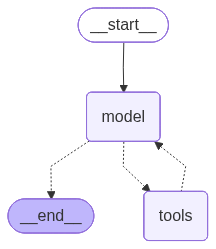

In [49]:
agent

In [50]:
config = {"configurable": {"thread_id": "session-1"}}

response = agent.invoke(
    {"messages": [HumanMessage("What is Apple's total revenue?")]},
    config=config,
)

2026-04-10 18:04:51,624 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: Apple total revenue...


In [52]:
print(response["messages"][-1].text)

Based on Apple's financial documents:

**Apple's Total Revenue by Fiscal Year:**

- **Fiscal Year 2025** (ended September 27, 2025): **$416.161 billion**
- **Fiscal Year 2024** (ended September 28, 2024): **$391.035 billion**
- **Fiscal Year 2023** (ended September 30, 2023): **$383.285 billion**
- **Fiscal Year 2022** (ended September 24, 2022): **$394.328 billion**

Apple's total revenue has been growing steadily in recent fiscal years, with a notable increase in 2025 compared to previous years.

Would you like more detailed information about Apple's revenue breakdown by segment or category?


In [53]:
response = agent.invoke(
    {"messages": [HumanMessage("What is Apple's and googles total revenue in 2020?")]},
    config=config,
)

2026-04-10 18:08:50,189 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: Apple total revenue 2020...
2026-04-10 18:08:50,216 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: Google total revenue 2020...
2026-04-10 18:09:20,007 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: Apple total revenue 2020...
2026-04-10 18:09:20,028 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: Google total revenue 2020...
2026-04-10 18:09:57,269 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: Apple revenue 2020 fiscal year...
2026-04-10 18:10:36,324 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: Apple revenue 2020 calendar year fiscal year 2021...


In [55]:
print(response["messages"][-1].text)

Based on the Apple 10-K documents I've searched, I have financial data for fiscal years 2022-2025, but I don't have direct access to the 2020 fiscal year data in my current search results. However, I can provide you with the revenue information that's available:

**Apple Net Sales by Fiscal Year:**
- **FY 2025** (ended September 27, 2025): **$416.16 billion**
- **FY 2024** (ended September 28, 2024): **$391.04 billion**
- **FY 2023** (ended September 30, 2023): **$383.29 billion**
- **FY 2022** (ended September 24, 2022): **$394.33 billion**

**FY 2020 and Calendar Year 2020:**
The specific fiscal year 2020 data (ending September 26, 2020) and calendar year 2020 revenue are not available in my current document search results. Fiscal year 2020 data would typically be found in Apple's FY 2021 10-K (filed in October 2020), which is not included in the current document collection.

**Key observations from available data:**
- Apple's revenue has shown strong growth, with FY 2025 reaching $4

## 8. Filter-Aware Agent

Upgrade the agent with two tools: `get_filter_context` (inspect what's stored) and `search_documents` (retrieve with optional filters).
The model decides when to use filters based on the query.

We also upgrade the model to `qwen3.5:27b` for better multi-document reasoning.

In [56]:
query = "what is apple's revenue in 2025?"
filter_context = rag.get_filter_context(query=query)

2026-04-10 18:20:29,463 - ragwire.core.pipeline - INFO - Auto-extracted filters from query: {'company_name': 'apple inc.', 'fiscal_year': 2025}


In [58]:
print(filter_context)

## RAGWire Filter Context

### Available Metadata Fields and Stored Values
- **company_name**: ['alphabet inc.', 'apple inc.', 'amazon.com inc.']
- **doc_type**: ['10-k']
- **fiscal_year**: [2024, 2025]
- **fiscal_quarter**: ['null']

### Extracted Filters from Query
- **company_name**: `apple inc.`
- **fiscal_year**: `2025`

### Instructions
1. Review the extracted filters above.
2. If an extracted value does not match or closely relate to any stored value, adjust or drop that filter.
3. If the query has no clear metadata intent, pass an empty dict `{}` as filters.
4. Pass the final filters dict to the retrieval tool as `filters=`.


In [59]:
@tool
def get_filter_context(query: str) -> str:
    """Get available metadata fields, stored values, and filter suggestions for a query.

    Call this before search_documents when the query involves a specific company,
    year, or document type. Skip for purely semantic queries.
    """
    return rag.get_filter_context(query)

In [60]:
@tool
def search_documents(query: str, filters=None):
    """Search the document knowledge base for relevant information.

    Args:
        query: The search query
        filters: Optional metadata filters from get_filter_context.
    """

    results = rag.retrieve(query=query, filters=filters)

    if not results:
        return "No relevant information is found!"
    else:
        return results 

In [63]:
agent = create_agent(
    # model=ChatOllama(model="qwen3.5:27b"),
    model=ChatOllama(model="qwen3.5:9b"),
    tools=[get_filter_context, search_documents],
    system_prompt=(
        "You are a helpful financial document assistant. "
        "For complex questions, break them down into simple sub-questions. "
        "Always use search_documents to retrieve information — never answer from general knowledge. "
        "Use get_filter_context before search_documents when the query involves specific metadata. "
        "Always cite the source document in your answer."
    ),
    checkpointer=InMemorySaver(),
)

## 9. Interactive Q&A Loop

Put it all together — the filter-aware agent in a conversational loop.

In [65]:
config = {"configurable": {"thread_id": "demo"}}

print("\nRAG Agent ready. Type 'quit' to exit.\n")

while True:
    question = input("You: ").strip()
    if question.lower() in ("quit", "exit", "q"):
        break
    if not question:
        continue
    response = agent.invoke(
        {"messages": [HumanMessage(question)]},
        config=config,
    )
    print(f"\nAgent: {response['messages'][-1].content}\n")


RAG Agent ready. Type 'quit' to exit.

2026-04-10 18:40:08,041 - ragwire.core.pipeline - INFO - Auto-extracted filters from query: {'company_name': 'apple inc.', 'fiscal_year': 2025}
2026-04-10 18:40:16,068 - ragwire.core.pipeline - INFO - Retrieved 0 documents for query: Apple revenue 2025...

Agent: Based on the information retrieved, there is no relevant data available regarding Apple's revenue for the fiscal year 2025. The available documents do not contain the specific revenue figures you are looking for.

